Target distribution:
 fire
1    270
0    247
Name: count, dtype: int64

Training SVM...

===== SVM =====
Accuracy : 0.6057692307692307
Precision: 0.6
Recall   : 0.7222222222222222
RMSE     : 0.46991529448360203


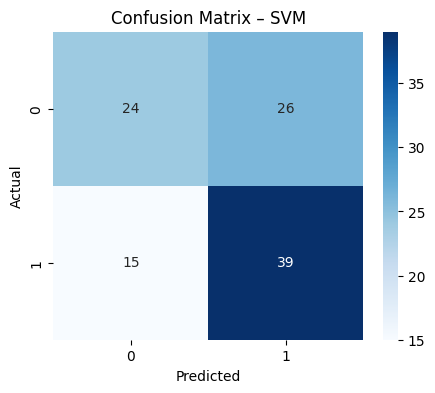


Training MLP...

===== MLP =====
Accuracy : 0.8076923076923077
Precision: 0.8035714285714286
Recall   : 0.8333333333333334
RMSE     : 0.35363272520416716


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


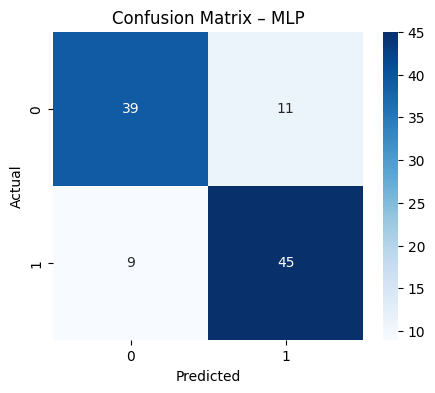


Training GradientBoosting...

===== GradientBoosting =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
RMSE     : 2.1882115835332484e-05


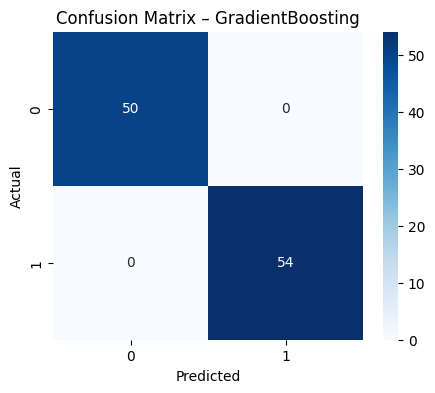


Training ANN_Keras...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

===== ANN_Keras =====
Accuracy : 0.7019230769230769
Precision: 0.7017543859649122
Recall   : 0.7407407407407407
RMSE     : 0.4264923771661105


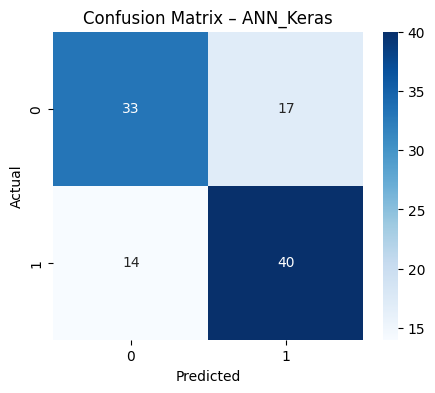

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, mean_squared_error
)

import tensorflow as tf
from tensorflow.keras import layers, models


# ============================================================
# 2. LOADING DATA
# ============================================================
paulo = pd.read_csv("forestfires.csv")


# ============================================================
# 3. CREATING BINARY TARGET (fire / no fire)
# ============================================================
paulo["fire"] = (paulo["area"] > 0).astype(int)
print("Target distribution:\n", paulo["fire"].value_counts())


# ============================================================
# 4. FEATURES
# ============================================================
FEATURES = [
    "X","Y","month","day","FFMC","DMC","DC",
    "ISI","temp","RH","wind","rain","area"
]

# Encoding month/day (string → number)
paulo["month"] = paulo["month"].astype("category").cat.codes
paulo["day"]   = paulo["day"].astype("category").cat.codes

X = paulo[FEATURES].values
y = paulo["fire"].values


# ============================================================
# 5. TRAIN–TEST SPLIT (80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ============================================================
# 6. SCALING
# ============================================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


# ============================================================
# 7. HELPER FUNCTIONS
# ============================================================
def evaluate_model(name, y_true, probs):
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec  = recall_score(y_true, preds, zero_division=0)
    rmse = np.sqrt(mean_squared_error(y_true, probs))

    print(f"\n===== {name} =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("RMSE     :", rmse)

    return preds


def plot_confusion(name, y_true, preds):
    cm = confusion_matrix(y_true, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ============================================================
# 8. MODELS
# ============================================================
models = {
    "SVM": SVC(probability=True, class_weight="balanced"),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400),
    "GradientBoosting": GradientBoostingClassifier()
}


# ============================================================
# 9. TRAINING + EVALUATING CLASSIC MODELS
# ============================================================
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_s, y_train)

    probs = model.predict_proba(X_test_s)[:,1]
    preds = evaluate_model(name, y_test, probs)
    plot_confusion(name, y_test, preds)


    if name == "GradientBoosting":
        gb_model = model




# ============================================================
# 11. KERAS ANN MODEL
# ============================================================
ann = models = tf.keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining ANN_Keras...")
ann.fit(X_train_s, y_train, epochs=20, batch_size=32, verbose=0)

probs_ann = ann.predict(X_test_s).flatten()
preds_ann = evaluate_model("ANN_Keras", y_test, probs_ann)
plot_confusion("ANN_Keras", y_test, preds_ann)
